### A TEMPLATE PROGRAM FOR SOLVING LINEAR REGRESSION (FOR EXAM)

#### 1 IMPORT THE LIBRARY

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt

#### 2 LOAD THE DATASET

In [4]:
iris=datasets.load_iris()
x=iris.data[:,2].reshape(-1,1) # Petal length
y=iris.data[:,3] # Petal width
print(x.shape)
print(y.shape)

(150, 1)
(150,)


#### 3 SPLIT THE DATASET

In [5]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 1)
(30, 1)
(120,)
(30,)


#### 4 CREATE MODEL

In [6]:
model=LinearRegression()

#### 5 FIT THE MODEL

In [7]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### PRINT SLOPE AND INTERCEPT

In [9]:
slope=model.coef_[0]
intercept=model.intercept_
print(f"the slope is {slope:.2f} and the intercept is {intercept:.2f}")

the slope is 0.41 and the intercept is -0.36


#### REGRESSION LINE EQUATION

In [10]:
print(f"the linear regression is y= {intercept:.2f} + {slope:.2f}*x")

the linear regression is y= -0.36 + 0.41*x


In [15]:
# for x=90 the value of y is 36.83
prediction=model.predict([[90]])
print(prediction)

[36.83477839]


#### PREDICTION

In [16]:
y_pred=model.predict(x_test)
print(y_pred)

[1.58555194 0.34583706 2.49467619 1.50290428 1.62687577 0.2631894
 1.13098982 1.75084726 1.50290428 1.2549613  1.75084726 0.22186557
 0.18054174 0.2631894  0.2631894  1.58555194 2.04011406 1.2549613
 1.50290428 1.9574664  0.30451323 1.6681996  0.30451323 1.9574664
 2.28805704 1.79217109 2.04011406 2.08143789 0.22186557 0.30451323]


#### EVALUATION

In [17]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"Mean squared Error is {mse:.2f} and r2 score is {r2:.2f}")

Mean squared Error is 0.05 and r2 score is 0.93


#### PLOT THE REGRESSION LINE (OPTIONAL)

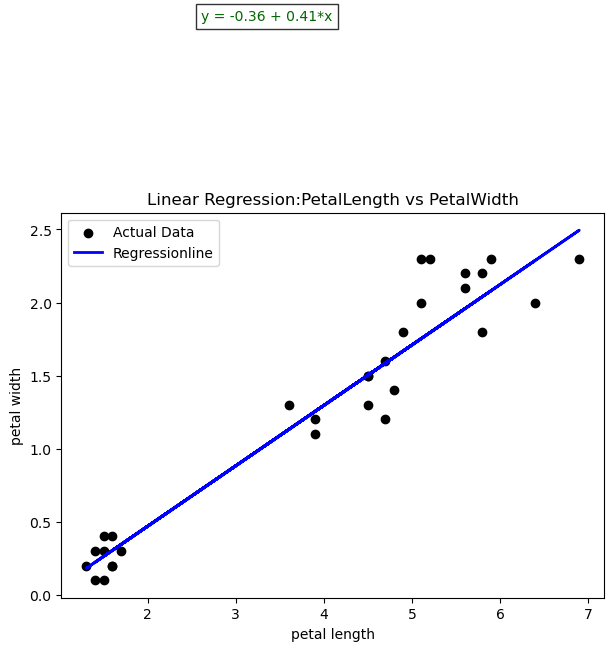

In [23]:
plt.figure(figsize=(7,5))
plt.scatter(x_test,y_test,color='black',label='Actual Data')
plt.plot(x_test,y_pred,color='blue',label='Regressionline',linewidth=2)
plt.xlabel("petal length")
plt.ylabel("petal width")
plt.title("Linear Regression:PetalLength vs PetalWidth")
plt.legend()
x_min,x_max=plt.xlim()
y_min,y_max=plt.ylim()
equation=f"y = {intercept:.2f} + {slope:.2f}*x"
plt.text(
    x_max-0.5*(x_max-x_min),
    y_max+0.5*(y_max-y_min),
    equation,fontsize=10,color='darkgreen',ha="right",
    bbox=dict(facecolor='white',alpha=0.8)
)
plt.show()

#### WRITE A PROGRAM TO PREDICT THE TIME TO COMPLETE 100M RACE

In [25]:
df=pd.read_csv("olympic100m.csv")
df

,year,time
0,1896,12.00
1,1900,11.00
2,1904,11.00
3,1906,11.20
4,1908,10.80
5,1912,10.80
6,1920,10.80
7,1924,10.60
8,1928,10.80
9,1932,10.30


In [37]:
x=df["year"]
y=df["time"]
x=np.array(x).reshape(-1,1)
y=np.array(y)
print(x.shape)
print(y.shape)

(29, 1)
(29,)


In [44]:
model=LinearRegression()
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
prediction=model.predict([[2025]])
print(prediction)

[9.46236941]


In [46]:
ypred=model.predict(x)
r2_score(y,ypred)

0.8244024591775609

In [47]:
mean_squared_error(y,ypred)

0.048983570840599545

#### LR USING STATSMODELS

In [48]:
import numpy as np
import statsmodels.api as sm

In [50]:
x=np.array([60,62,67,70,71,72,75,78]).reshape(-1,1)
y=np.array([140,155,159,179,192,200,212,215])
# add constant
x_withconstant=sm.add_constant(x)
model=sm.OLS(y,x_withconstant).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     95.84
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           6.54e-05
Time:                        04:56:05   Log-Likelihood:                -26.115
No. Observations:                   8   AIC:                             56.23
Df Residuals:                       6   BIC:                             56.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -124.1312     31.326     -3.963      0.0